# Instrument simulator

Generates "realistic" data products based on input source spectrum, instrument throughput parameters, dispersion, lens vignetting, and detector response.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.time import Time
from astropy import units as u
from astropy.coordinates import SkyCoord
from shared_data import CSV_FILES, REFERENCE_SPECTRA
from sim import LongSlitWCS, ThroughputCurve, AtmosphericExtinction, DetectorModel, SpectrographModel, InstrumentSimulator, read_snifs_spectrum

In [2]:
# spec = np.loadtxt(REFERENCE_SPECTRA["SNIa_max_z0p05"])
spec = read_snifs_spectrum(REFERENCE_SPECTRA["tns_2026neb_2026-06-23_10-31-59_UH88_SNIFS_SCAT"])
wave = spec.data["wl"]*u.AA
flux = spec.data["fl"]*u.erg/u.s/u.cm**2/u.AA
flux_err = spec.data["err"]*u.erg/u.s/u.cm**2/u.AA

In [3]:
fiber_wav, fiber_att = np.loadtxt(CSV_FILES["fiber_attenuation"], delimiter=",").T
fiber_tx = 10 ** (-(fiber_att * (10. / 1000.)) / 10)
fiber = ThroughputCurve(fiber_wav*u.nm, fiber_tx, name="fiber")

In [4]:
misc_losses = ThroughputCurve(wavelength=np.array([3000, 10500]) * u.AA, throughput=np.array([0.95, 0.95]), name="misc.")

atmosphere = AtmosphericExtinction(airmass=1.3) 

collimator = ThroughputCurve.from_csv(CSV_FILES["thorlabs_ar_coating"], name="collimator")

filter = ThroughputCurve.from_csv(CSV_FILES["FGL400S_transmission"], name="longpass filter")

grating = ThroughputCurve.from_csv(CSV_FILES["master 1294 unpolarized"], name="grating")

qe = ThroughputCurve.from_csv(CSV_FILES["gsense400bsi_qe"], name="detector QE")

window = ThroughputCurve.from_csv(CSV_FILES["UVFS_coating"], name="detector window")

detector = DetectorModel(
    nx=2048,
    ny=2048,
    pixel_size=11*u.micron,
    gain=0.478*u.electron/u.adu,
    read_noise=1.6*u.electron,
    dark_current=0.4*u.electron/u.s,
    bias=200.0*u.adu,
    full_well=90000.0*u.electron,
)

spectrograph = SpectrographModel(
    detector=detector,
    groove_density=300/u.mm,
    incidence_angle=32*u.deg,
    diffraction_angle=-20*u.deg,
    collimator_focal_length=180*u.mm,
    camera_focal_length=100*u.mm,
    fiber_core_diameter=105*u.um,
    diffraction_order=1,
    fiber_count=7,
    fiber_pitch=250*u.um,
)

sim = InstrumentSimulator(
    spectrograph=spectrograph,
    throughputs=[atmosphere, fiber, misc_losses, collimator, grating, window, qe],
)

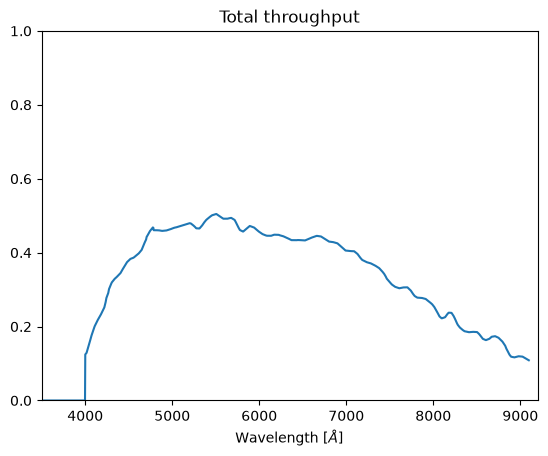

In [5]:
plt.plot(wave, sim.combined_throughput(wave))
plt.xlim(3500, 9200)
plt.ylim(0, 1)
plt.xlabel(r"Wavelength [$\AA$]")
plt.title("Total throughput")
plt.show()

In [6]:
def camera_lens_vignetting(yy, xx):
    x0 = detector.nx / 2
    y0 = detector.ny / 2

    rx = (xx - x0) / x0
    ry = (yy - y0) / y0
    r2 = rx**2 + ry**2

    return 1.0 - 0.2 * r2

exptime = spec.header["EXPTIME"] * u.s
obs_time = Time(spec.header["DATE-OBS"], format="fits")
fiber_fluxes = np.stack([flux] * 7)

image_adu = sim.simulate(
    wavelength=wave,
    flux_density=fiber_fluxes,
    exposure=exptime,
    vignetting=camera_lens_vignetting,
    add_noise=True,
    seed=123,
)
image_adu = np.round(image_adu.to_value(u.adu)).astype(np.uint16)

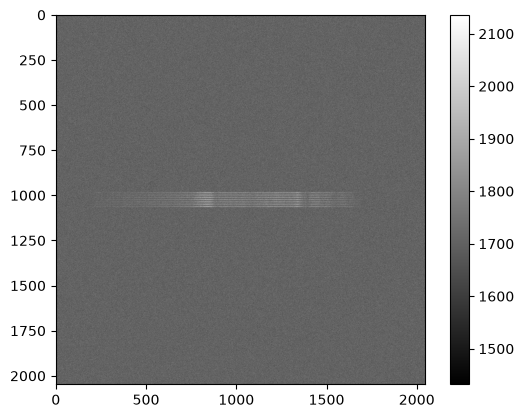

In [7]:
plt.imshow(image_adu, cmap="binary_r")
# plt.ylim(1000, 1048)
plt.colorbar()
plt.show()

In [8]:
reference_coord = SkyCoord(ra=spec.header["RA"], dec=spec.header["DEC"], unit=("hourangle", "deg"), frame="icrs")
slit_position_angle_deg = 0.

wcs = LongSlitWCS.from_instrument(
    nx=detector.nx,
    ny=detector.ny,
    ra_deg=reference_coord.ra.deg,
    dec_deg=reference_coord.dec.deg,
    position_angle_deg=slit_position_angle_deg,
    reference_pixel=(1023.5, 1023.5),
)

In [9]:
hdu = fits.PrimaryHDU(image_adu)
hdu.header["LOCATION"] = "Mt Laguna Observatory", "Observatory/location"
hdu.header["LATITUDE"] = 32.8722, "[deg N] Observatory latitude"
hdu.header["LONGITUD"] = -116.418, "[deg E] Observatory longitude"
hdu.header["TELESCOP"] = "Claud 1.25-m Telescope", "Telescope name"
hdu.header["INSTRUME"] = "<TBD excellent & clever name>", "Instrument name"
hdu.header["ORIGIN"] = "SDSU", "Originating institution"
hdu.header["OBSERVER"] = "Gobat", "Observer name(s)"

hdu.header["CAMERA"] = "FLI Kepler KL400", "Camera model"
hdu.header["CAMERAFL"] = 100., "[mm] Camera focal length"
hdu.header["COLLIMFL"] = 180., "[mm] Collimator focal length"
hdu.header["NGROOVES"] = 300., "[1/mm] Grating # of lines per mm"
hdu.header["GRATING"] = "270R", "Diffraction grating in use"
hdu.header["FILTER"] = "FGL400S", "Active filter"
hdu.header["DISPERS"] = 0.3455, "[nm/px] Nominal dispersion along spectral axis"

hdu.header["DETECTOR"] = "GSENSE400BSI", "Detector model"
hdu.header["PIXSIZE"] = 11., "[micron] Pixel size (unbinned)"
hdu.header["BINX"] = 1, "Horizontal binning"
hdu.header["BINY"] = 1, "Vertical binning"
hdu.header["BIAS"] = detector.bias.to_value(u.adu), "[ADU] Camera bias level"
hdu.header["EGAIN"] = detector.gain.to_value(u.electron/u.adu), "[e-/ADU] System gain"
hdu.header["CCD-TEMP"] = -20., "[degC] Sensor temperature during exposure"

hdu.header["OBJECT"] = spec.header["OBJECT"], "Target name"
hdu.header["RA"] = reference_coord.ra.to_string(unit="hourangle", sep=":"), "[H:M:S] Target right ascension"
hdu.header["DEC"] = reference_coord.dec.to_string(unit="deg", sep=":", alwayssign=True), "[D:M:S] Target declination"
hdu.header["RA_OBJ"] = round(reference_coord.ra.deg, 7), "[deg] Target right ascension"
hdu.header["DEC_OBJ"] = round(reference_coord.dec.deg, 7), "[deg] Target declination"
hdu.header["RA_TEL"] = round(reference_coord.ra.deg, 7), "[deg] Pointed telescope RA"
hdu.header["DEC_TEL"] = round(reference_coord.dec.deg, 7), "[deg] Pointed telescope declination"
hdu.header["RA_GCAM"] = round(reference_coord.ra.deg, 7), "[deg] Guide camera FOV center RA"
hdu.header["DEC_GCAM"] = round(reference_coord.dec.deg, 7), "[deg] Guide cam FOV center declination"

hdu.header["IMAGETYP"] = "Simulated", "Image type (light, dark, flat, wavecal, etc.)"
hdu.header["LAMPSTAT"] = False, "Calibration arc lamp state (T=on, F=off)"
hdu.header["STAGEX"] = 0., "Guider/fiber stage X position"
hdu.header["STAGEY"] = 0., "Guider/fiber stage Y position"
hdu.header["GUIDED"] = False, "Telescope autoguiding status during observation"
hdu.header["TELFOCUS"] = 383271., "Telescope focus position"
hdu.header["CAMFOCUS"] = 0, "Instrument camera lens focus position"
hdu.header["AIRMASS"] = spec.header["AIRMASS"], "Average airmass during observation"
hdu.header["EXPTIME"] = exptime.to_value(u.s), "[s] Exposure time"
hdu.header["MJD-OBS"] = round(obs_time.utc.mjd, 6), "[MJD] Observation start time"
hdu.header["DATE-OBS"] = obs_time.utc.isot, "Observation start time"
hdu.header["DATE-END"] = (obs_time + exptime).isot, "Observation end time"

hdu.header.update(wcs.to_header())
hdu.header.set("TIMESYS", "UTC", "Time system in use", before="RADESYS")
hdu.header.set("EQUINOX", 2000., "Coordinate system equinox", after="RADESYS")
hdu.header["WAVESOL"] = "APPROX", "Wavelength solution status"

hdu.header["FILENAME"] = "placeholder", "Name of this file when it was written"
hdu.header["DATE"] = Time.now().utc.isot, "HDU creation time"

hdu.header.add_comment("-"*20 + " PROVENANCE INFORMATION " + "-"*20, after="EXTEND")
hdu.header.add_comment("-"*20 + " INSTRUMENT CONFIGURATION " + "-"*20, after="OBSERVER")
hdu.header.add_comment("-"*24 + " SENSOR PARAMETERS " + "-"*24, before="DETECTOR")
hdu.header.add_comment("-"*26 + " TARGET/POINTING " + "-"*26, before="OBJECT")
hdu.header.add_comment("-"*22 + " OBSERVATION METADATA " + "-"*22, before="IMAGETYP")
hdu.header.add_comment("-"*30 + " TIMING " + "-"*30, before="EXPTIME")
hdu.header.add_comment("-"*20 + " WORLD COORDINATE SYSTEM " + "-"*20, before="WCSAXES")
hdu.header.add_comment("-"*24 + " FILE METADATA " + "-"*24, before="FILENAME")

In [10]:
hdu.writeto(f"simulated_{spec.header['OBJECT']}_spectrum.fits", overwrite=True)